In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [2]:
from google.colab import drive
import zipfile, os

drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Parkinson's Dataset Final.zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

BASE = "/content/dataset/Parkinson's Dataset Final"
print("Dataset extracted to:", BASE)
print("Inside BASE:", os.listdir(BASE))


Mounted at /content/drive
Dataset extracted to: /content/dataset/Parkinson's Dataset Final
Inside BASE: ['Hand Pd', 'New hand pd Dataset']


In [3]:
!pip install -q opencv-python tqdm

import os, cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


In [4]:
IMG_SIZE = 224

def preprocess_medical(img_gray):

    img = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))

    img = cv2.GaussianBlur(img, (3,3), 0)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    img = img.astype("float32") / 255.0

    img = np.expand_dims(img, axis=-1)

    return img


In [5]:
def load_images_recursive(folder_path, label):
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith((".png",".jpg",".jpeg",".bmp")):
                path = os.path.join(root, file)

                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue

                img = preprocess_medical(img)

                X.append(img)
                y.append(label)

X, y = [], []

NEW_ROOT = "/content/dataset/Parkinson's Dataset Final/New hand pd Dataset"

healthy_path   = os.path.join(NEW_ROOT, "Healthy")
parkinson_path = os.path.join(NEW_ROOT, "Parkinson's")

load_images_recursive(healthy_path, 0)
load_images_recursive(parkinson_path, 1)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("Final X shape:", X.shape)
print("Healthy:", np.sum(y==0))
print("Parkinson:", np.sum(y==1))


Final X shape: (512, 224, 224, 1)
Healthy: 233
Parkinson: 279


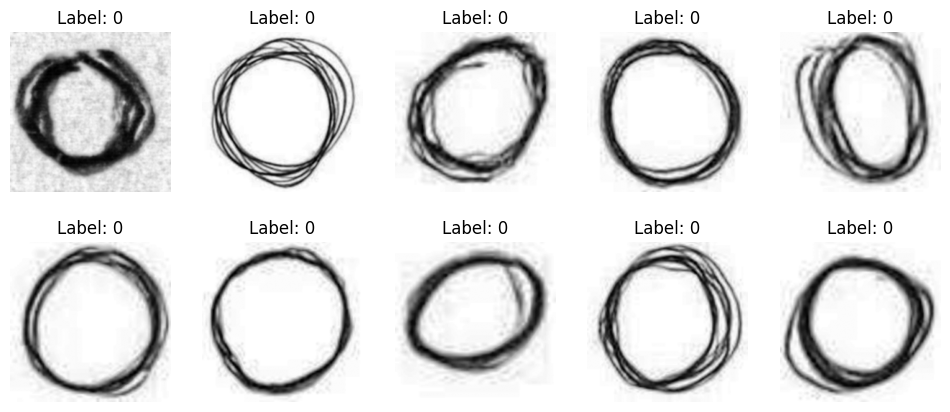

In [6]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title("Label: " + str(y[i]))
    plt.axis("off")

plt.show()


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train Healthy:", np.sum(y_train==0), "Train Parkinson:", np.sum(y_train==1))
print("Test Healthy:", np.sum(y_test==0), "Test Parkinson:", np.sum(y_test==1))


Train: (384, 224, 224, 1) Test: (128, 224, 224, 1)
Train Healthy: 175 Train Parkinson: 209
Test Healthy: 58 Test Parkinson: 70


In [8]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weights_dict)


Class weights: {0: np.float64(1.0971428571428572), 1: np.float64(0.9186602870813397)}


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, Model


In [10]:
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size=16, embed_dim=526, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="valid")

    def call(self, x):
        x = self.proj(x)  # (B, H/patch, W/patch, embed_dim)
        x = tf.reshape(x, (tf.shape(x)[0], -1, self.embed_dim))  # (B, num_patches, embed_dim)
        return x


In [11]:
class PositionalEncoding(layers.Layer):
    def __init__(self, num_patches, dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.dim = dim

    def build(self, input_shape):
        self.pos_embedding = self.add_weight(
            name="pos_embedding",
            shape=(1, self.num_patches, self.dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        return x + self.pos_embedding


In [12]:
class TransformerBlock(layers.Layer):
    def __init__(self, dim, num_heads=4, mlp_ratio=2, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim // num_heads, dropout=dropout)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

        self.mlp = tf.keras.Sequential([
            layers.Dense(dim * mlp_ratio, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(dim),
            layers.Dropout(dropout)
        ])

    def call(self, x, training=False):
        attn_out = self.attn(self.norm1(x), self.norm1(x), training=training)
        x = x + attn_out

        mlp_out = self.mlp(self.norm2(x), training=training)
        x = x + mlp_out

        return x


In [17]:
def build_custom_vit_feature_extractor():
    inputs = layers.Input(shape=(224, 224, 1))

    # Patch embedding
    x = PatchEmbedding(patch_size=16, embed_dim=526, name="patch_embedding")(inputs)

    # 224/16 = 14 → 14*14 = 196 patches
    x = PositionalEncoding(num_patches=196, dim=526, name="positional_encoding")(x)

    # ---- Stage 1: 526 ----
    x = TransformerBlock(dim=526, num_heads=2, dropout=0.1, name="transformer_block_0")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="ln_0")(x)
    x = layers.Dense(256, name="proj_526_to_256")(x)

    # ---- Stage 2: 256 ----
    x = TransformerBlock(dim=256, num_heads=4, dropout=0.1, name="transformer_block_1")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="ln_1")(x)
    x = layers.Dense(128, name="proj_256_to_128")(x)

    # ---- Stage 3: 128 ----
    x = TransformerBlock(dim=128, num_heads=4, dropout=0.1, name="transformer_block_2")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="ln_2")(x)
    x = layers.Dense(64, name="proj_128_to_64")(x)

    # ---- Stage 4: 64 ----
    x = TransformerBlock(dim=64, num_heads=4, dropout=0.1, name="transformer_block_3")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="ln_3")(x)
    x = layers.Dense(32, name="proj_64_to_32")(x)

    # ---- Stage 5: 32 ----
    x = TransformerBlock(dim=32, num_heads=4, dropout=0.1, name="transformer_block_4")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="ln_4")(x)
    x = layers.Dense(16, name="proj_32_to_16")(x)

    # ---- Stage 6: 16 ----
    x = TransformerBlock(dim=16, num_heads=2, dropout=0.1, name="transformer_block_5")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="ln_5")(x)
    x = layers.Dense(8, name="proj_16_to_8")(x)

    # ---- Stage 7: 8 ----
    x = TransformerBlock(dim=8, num_heads=2, dropout=0.1, name="transformer_block_6")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="ln_6")(x)
    x = layers.Dense(4, name="proj_8_to_4")(x)

    # ---- Stage 8: 4 ----
    x = TransformerBlock(dim=4, num_heads=1, dropout=0.05, name="transformer_block_7")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="ln_7")(x)
    x = layers.Dense(2, name="proj_4_to_2")(x)

    # ---- Stage 9: 2 ----
    x = TransformerBlock(dim=2, num_heads=1, dropout=0.05, name="transformer_block_8")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="ln_8")(x)
    x = layers.Dense(1, name="proj_2_to_1")(x)

    # Final feature pooling
    x = layers.GlobalAveragePooling1D(name="vit_final_feature")(x)
    x = layers.Activation("sigmoid", name="vit_sigmoid_output")(x)


    model = Model(inputs, x, name="Custom_ViT_Feature_Extractor")
    return model

vit_extractor = build_custom_vit_feature_extractor()
vit_extractor.summary()


Model: "Custom_ViT_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 196, 526)       │       103,096 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 196, 526)       │     2,219,194 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_0 (LayerNormalization)       │ (None, 196, 526)       │         1,052 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_526_to_256 (Dense)         │ (None, 196, 256)       │       134,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 196, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_1 (LayerNormalization)       │ (None, 196, 256)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_256_to_128 (Dense)         │ (None, 196, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 196, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_2 (LayerNormalization)       │ (None, 196, 128)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_128_to_64 (Dense)          │ (None, 196, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 196, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_3 (LayerNormalization)       │ (None, 196, 64)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_64_to_32 (Dense)           │ (None, 196, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 196, 32)        │         8,544 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_4 (LayerNormalization)       │ (None, 196, 32)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_32_to_16 (Dense)           │ (None, 196, 16)        │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 196, 16)        │         2,224 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_5 (LayerNormalization)       │ (None, 196, 16)        │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_16_to_8 (Dense)            │ (None, 196, 8)         │           13

 Total params: 3,343,051 (12.75 MB)

 Trainable params: 3,343,051 (12.75 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
probe_input = layers.Input(shape=(1,))
probe_output = layers.Dense(1, activation="sigmoid")(probe_input)

probe_model = Model(probe_input, probe_output, name="ProbeHead")


In [15]:
inputs = layers.Input(shape=(224,224,1))
feat = vit_extractor(inputs)
out = layers.Dense(1, activation="sigmoid")(feat)

vit_probe_model = Model(inputs, out, name="MiniViT_Probe_Model")


In [18]:
vit_probe_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

history_probe = vit_probe_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5207 - loss: 0.7055
Epoch 1: val_loss did not improve from 0.68876
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 371ms/step - accuracy: 0.5216 - loss: 0.7052 - val_accuracy: 0.5469 - val_loss: 0.6892 - learning_rate: 1.0000e-04
Epoch 2/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5395 - loss: 0.6994
Epoch 2: val_loss did not improve from 0.68876
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5397 - loss: 0.6993 - val_accuracy: 0.5469 - val_loss: 0.6892 - learning_rate: 1.0000e-04
Epoch 3/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5449 - loss: 0.6975
Epoch 3: val_loss did not improve from 0.68876
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5449 - loss: 0.6975 - val_accuracy: 0.5469 - val_loss: 0.6892 - learning_rate: 1.0000e-04
Epoch 4/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5293 - loss: 0.7022
Epoch 4: val_loss did not improve from 0.68876

Epoch 4: ReduceLROnPlateau reducing l